# Phase 1: Text representation

## Research Question

How can text be converted into numerical representations that allow a computer to compare documents?

## Objectives

1. Load a text corpus
2. Tokenize text
3. Implement Bag of Words
4. Implement TF - IDF (Term Frequency - Inverse Document Frequency)
5. Calculate cosine similarity
6. Analyze the limitations of simple text representations


In [40]:
from pathlib import Path
file_path = Path("../data/sample_texts.txt")
with open(file_path, "r") as file:
    documents = file.readlines()

documents = [doc.strip() for doc in documents if doc.strip()]

for i, document in enumerate(documents):
    print(f"Document {i + 1}: {document}")

Document 1: The cat sat on the mat.
Document 2: The dog sat beside the cat.
Document 3: The bank approved the loan.
Document 4: She deposited money in the bank.
Document 5: They sat on the bank of the river.
Document 6: The river flowed beside the bank.
Document 7: Machine learning models learn patterns from data.
Document 8: Deep learning is a branch of machine learning.


In [41]:
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

sentence = documents[0]

tokens = tokenize(sentence)

print("Original sentence:")
print(sentence)
print("\nTokens:")
print(tokens)

Original sentence:
The cat sat on the mat.

Tokens:
['the', 'cat', 'sat', 'on', 'the', 'mat']


In [42]:
#Building a vocabulary: collection of unique words in our corpus.
vocabulary = set()
for document in documents:
    tokens = tokenize(document)
    vocabulary.update(tokens)

vocabulary = sorted(vocabulary)

print(vocabulary)
print(f"\nVocabulary size: {len(vocabulary)}")

['a', 'approved', 'bank', 'beside', 'branch', 'cat', 'data', 'deep', 'deposited', 'dog', 'flowed', 'from', 'in', 'is', 'learn', 'learning', 'loan', 'machine', 'mat', 'models', 'money', 'of', 'on', 'patterns', 'river', 'sat', 'she', 'the', 'they']

Vocabulary size: 29


In [43]:
#creating an index of the words
word_to_index = {
    word: index for index, word in enumerate(vocabulary)
    }
print(word_to_index)

{'a': 0, 'approved': 1, 'bank': 2, 'beside': 3, 'branch': 4, 'cat': 5, 'data': 6, 'deep': 7, 'deposited': 8, 'dog': 9, 'flowed': 10, 'from': 11, 'in': 12, 'is': 13, 'learn': 14, 'learning': 15, 'loan': 16, 'machine': 17, 'mat': 18, 'models': 19, 'money': 20, 'of': 21, 'on': 22, 'patterns': 23, 'river': 24, 'sat': 25, 'she': 26, 'the': 27, 'they': 28}


In [44]:
#implementing a Bag-of-Words (BoW) representation
import numpy as np

def bag_of_words(text, word_to_index):
    tokens = tokenize(text)

    vector = np.zeros(len(word_to_index), dtype=int)

    for token in tokens:
        if token in word_to_index:
            index = word_to_index[token]
            vector[index] += 1

    return vector

sentence = "The dog sat"

vector = bag_of_words(sentence, word_to_index)

print("Vocabulary:")
print(vocabulary)

print("\nSentence:")
print(sentence)

print("\nBag-of-Words Vector:")
print(vector)

Vocabulary:
['a', 'approved', 'bank', 'beside', 'branch', 'cat', 'data', 'deep', 'deposited', 'dog', 'flowed', 'from', 'in', 'is', 'learn', 'learning', 'loan', 'machine', 'mat', 'models', 'money', 'of', 'on', 'patterns', 'river', 'sat', 'she', 'the', 'they']

Sentence:
The dog sat

Bag-of-Words Vector:
[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]


In [45]:
#matrix to represent all documents in the corpus
bow_matrix = []

for document in documents:
    vector = bag_of_words(document, word_to_index)
    bow_matrix.append(vector)

bow_matrix = np.array(bow_matrix)

print("Shape:", bow_matrix.shape)
print(bow_matrix)

Shape: (8, 29)
[[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 2 0]
 [0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 2 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 2 1]
 [0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0]
 [0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 2 0 1 0 0 0 1 0 0 0 0 0 0 0]]


## TF-IDF
Bag of Words treats all words as equally important.
TF-IDF improves this by assigning higher importance to words that occur frequently in a document but rarely across the entire corpus.

In [46]:
import math

def calculate_idf(documents, vocabulary):
    total_documents = len(documents)
    idf = {}

    for word in vocabulary:
        document_frequency = 0

        for document in documents:
            tokens = tokenize(document)
            if word in tokens:
                document_frequency += 1

        idf[word] = math.log(total_documents / (document_frequency + 1))

    return idf

idf_scores = calculate_idf(documents, vocabulary)
for word, score in idf_scores.items():
    print(f"Word: {word}, IDF: {score:.3f}")

Word: a, IDF: 1.386
Word: approved, IDF: 1.386
Word: bank, IDF: 0.470
Word: beside, IDF: 0.981
Word: branch, IDF: 1.386
Word: cat, IDF: 0.981
Word: data, IDF: 1.386
Word: deep, IDF: 1.386
Word: deposited, IDF: 1.386
Word: dog, IDF: 1.386
Word: flowed, IDF: 1.386
Word: from, IDF: 1.386
Word: in, IDF: 1.386
Word: is, IDF: 1.386
Word: learn, IDF: 1.386
Word: learning, IDF: 0.981
Word: loan, IDF: 1.386
Word: machine, IDF: 0.981
Word: mat, IDF: 1.386
Word: models, IDF: 1.386
Word: money, IDF: 1.386
Word: of, IDF: 0.981
Word: on, IDF: 0.981
Word: patterns, IDF: 1.386
Word: river, IDF: 0.981
Word: sat, IDF: 0.693
Word: she, IDF: 1.386
Word: the, IDF: 0.134
Word: they, IDF: 1.386


In [47]:
def calculate_tf(text):
    tokens = tokenize(text)
    total_words = len(tokens)

    tf = {}
    for word in tokens:
        tf[word] = tf.get(word, 0) + 1

    # Normalize TF values
    for word in tf:
        tf[word] /= total_words

    return tf

sentence = "The cat sat on the mat"

tf_scores = calculate_tf(sentence)

print(tf_scores)

{'the': 0.3333333333333333, 'cat': 0.16666666666666666, 'sat': 0.16666666666666666, 'on': 0.16666666666666666, 'mat': 0.16666666666666666}


In [48]:
def calculate_tfidf(text, word_to_index, idf_scores):
    tf_scores = calculate_tf(text)

    vector = np.zeros(len(word_to_index))

    for word, tf_value in tf_scores.items():
        if word in word_to_index:
            index = word_to_index[word]
            tfidf_value = tf_value * idf_scores[word]
            vector[index] = tfidf_value

    return vector

tfidf_vector = calculate_tfidf(
    documents[0],
    word_to_index,
    idf_scores)

for word, index in word_to_index.items():
    if tfidf_vector[index] > 0:
        print(f"Word: {word}, TF-IDF: {tfidf_vector[index]:.3f}")


Word: cat, TF-IDF: 0.163
Word: mat, TF-IDF: 0.231
Word: on, TF-IDF: 0.163
Word: sat, TF-IDF: 0.116
Word: the, TF-IDF: 0.045


In [49]:
#Cosine similarity function
def cosine_similarity(vector_a, vector_b):
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)

    if magnitude_a == 0 or magnitude_b == 0:
        return 0

    return dot_product / (magnitude_a * magnitude_b)

tfidf_matrix = []

for document in documents:
    vector = calculate_tfidf(document, word_to_index, idf_scores)
    tfidf_matrix.append(vector)

tfidf_matrix = np.array(tfidf_matrix)

print(tfidf_matrix.shape)

doc_1 = tfidf_matrix[0]
doc_2 = tfidf_matrix[1]

similarity = cosine_similarity(doc_1, doc_2)
print(f"Similarity: {similarity:.3f}")

doc_3 = tfidf_matrix[2]

similarity = cosine_similarity(doc_1, doc_3)
print(f"Similarity: {similarity:.3f}")

(8, 29)
Similarity: 0.344
Similarity: 0.017


In [50]:
num_documents = len(documents)

similarity_matrix = np.zeros((num_documents, num_documents))

for i in range(num_documents):
    for j in range(num_documents):
        similarity_matrix[i][j] = cosine_similarity(tfidf_matrix[i], tfidf_matrix[j])

print(similarity_matrix)

[[1.         0.34423047 0.01672378 0.00604033 0.30557645 0.01671926
  0.         0.        ]
 [0.34423047 1.         0.01672378 0.00604033 0.11138158 0.24223509
  0.         0.        ]
 [0.01672378 0.01672378 1.         0.04481134 0.0608271  0.07063768
  0.         0.        ]
 [0.00604033 0.00604033 0.04481134 1.         0.03857723 0.04479921
  0.         0.        ]
 [0.30557645 0.11138158 0.0608271  0.03857723 1.         0.26100305
  0.         0.11100298]
 [0.01671926 0.24223509 0.07063768 0.04479921 0.26100305 1.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  1.         0.23164445]
 [0.         0.         0.         0.         0.11100298 0.
  0.23164445 1.        ]]


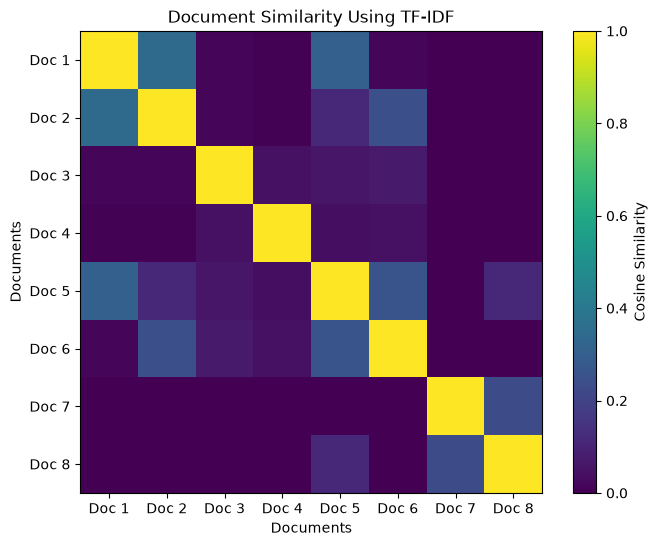

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(similarity_matrix)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(num_documents), [f'Doc {i+1}' for i in range(num_documents)])
plt.yticks(range(num_documents), [f'Doc {i+1}' for i in range(num_documents)])

plt.title("Document Similarity Using TF-IDF")
plt.xlabel("Documents")
plt.ylabel("Documents")

plt.show()

## Findings and Limitations

### What Bag of Words and TF-IDF can do

- Convert text into numerical vectors.
- Measure word frequency
- Identify important words
- Compare documents using mathematical similarity

### Limitations
- They do not understand semantic 
- They treat identical words as identical concepts
- They ignore deeper context
- They struggle with synonyms
- They cannot distinguish different meanings of ambiguous words
For example, "The bank approved the loan" and "They sat on the bank of the river", both contain the same token "bank", but TF-IDF cannot determine that the word has different meanings in each context.


# Phase 2: Word Embeddings

# Research Question
How can a computer represent the meaning/relationships of words as vectors?

## Objectives
- Understand vectors and semantic space
- Use pretrained embeddings
- Visualize word relationships
- Understand Word2Vec: including how it learns embeddings

In [52]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")

vector = model['cat']

print(vector)
print(vector.shape)

[ 0.45281  -0.50108  -0.53714  -0.015697  0.22191   0.54602  -0.67301
 -0.6891    0.63493  -0.19726   0.33685   0.7735    0.90094   0.38488
  0.38367   0.2657   -0.08057   0.61089  -1.2894   -0.22313  -0.61578
  0.21697   0.35614   0.44499   0.60885  -1.1633   -1.1579    0.36118
  0.10466  -0.78325   1.4352    0.18629  -0.26112   0.83275  -0.23123
  0.32481   0.14485  -0.44552   0.33497  -0.95946  -0.097479  0.48138
 -0.43352   0.69455   0.91043  -0.28173   0.41637  -1.2609    0.71278
  0.23782 ]
(50,)


In [53]:
model.most_similar('cat')
# model.most_similar('bank')


[('dog', 0.9218006134033203),
 ('rabbit', 0.8487821221351624),
 ('monkey', 0.8041081428527832),
 ('rat', 0.7891963124275208),
 ('cats', 0.7865270376205444),
 ('snake', 0.7798910737037659),
 ('dogs', 0.7795814871788025),
 ('pet', 0.7792249321937561),
 ('mouse', 0.773166835308075),
 ('bite', 0.7728800177574158)]

In [54]:
model.similarity('cat', 'dog')

np.float32(0.9218005)

In [55]:
model["bank"]

array([ 0.66488 , -0.11391 ,  0.67844 ,  0.17951 ,  0.6828  , -0.47787 ,
       -0.30761 ,  0.17489 , -0.70512 , -0.55022 ,  0.1514  ,  0.10214 ,
       -0.45063 , -0.33069 ,  0.056133,  1.2271  ,  0.55607 , -0.68297 ,
        0.037364,  0.70266 ,  1.9093  , -0.61483 , -0.83329 , -0.3023  ,
       -1.1118  , -1.55    ,  0.2604  ,  0.22957 , -1.0375  , -0.31789 ,
        3.5091  , -0.25871 ,  1.0151  ,  0.65927 , -0.18231 , -0.75859 ,
       -0.30927 , -0.91678 ,  1.0633  , -0.66761 , -0.37464 , -0.29143 ,
        0.65606 , -0.44642 , -0.075495, -1.0552  , -0.60501 ,  0.73582 ,
        1.0139  , -0.27749 ], dtype=float32)

In [56]:
#Visualizing the word embeddings using PCA
words = [
    "cat",
    "dog",
    "lion",
    "tiger",
    "car",
    "bus",
    "train",
    "computer",
    "software",
    "bank",
    "money",
    "river"
]

vectors = [model[word] for word in words]

import scikit-learn as sklearn
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

#Plotting the 2D representation of the word embeddings
plt.figure(figsize=(10, 7))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title("Word Embeddings Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

SyntaxError: invalid syntax (4228500440.py, line 19)